Dataset Loaded Successfully

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Missing Values After Cleaning:
 crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

================ RESULTS ================
Simple Linear Regression MSE : 46.176936738355245
Multiple Linear Reg

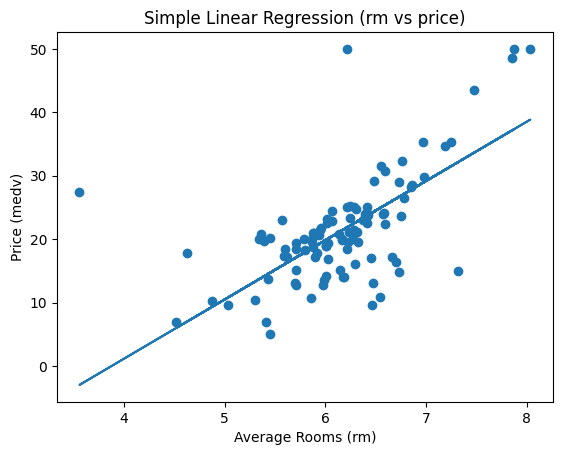

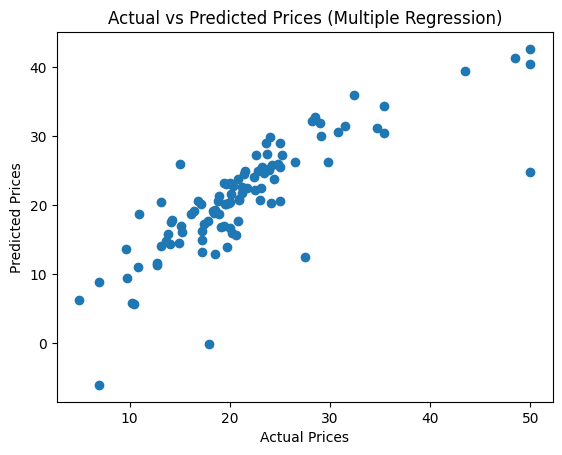

In [1]:
# =========================================================
# DATA ANALYTICS I - BOSTON HOUSING LINEAR REGRESSION
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# =========================================================
# 1. LOAD DATASET
# =========================================================

df = pd.read_csv("BostonHousing.csv")

print("Dataset Loaded Successfully\n")
print(df.head())

# =========================================================
# 2. DATA CLEANING
# =========================================================

# Convert all columns to numeric (handles blank values)
df = df.apply(pd.to_numeric, errors='coerce')

# Fill missing values with column mean
df.fillna(df.mean(), inplace=True)

print("\nMissing Values After Cleaning:\n", df.isnull().sum())

# =========================================================
# 3. SIMPLE LINEAR REGRESSION (Using 'rm')
# =========================================================

X_simple = df[['rm']]   # Average number of rooms
y = df['medv']         # Price

# Split data
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Train model
simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

# Predictions
y_pred_s = simple_model.predict(X_test_s)

# MSE
mse_simple = mean_squared_error(y_test_s, y_pred_s)

# =========================================================
# 4. MULTIPLE LINEAR REGRESSION (All Features)
# =========================================================

X_multi = df.drop('medv', axis=1)

# Split data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

# Train model
multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

# Predictions
y_pred_m = multi_model.predict(X_test_m)

# MSE
mse_multi = mean_squared_error(y_test_m, y_pred_m)

# =========================================================
# 5. RESULTS
# =========================================================

print("\n================ RESULTS ================")
print("Simple Linear Regression MSE :", mse_simple)
print("Multiple Linear Regression MSE :", mse_multi)

# =========================================================
# 6. PLOT: SIMPLE REGRESSION LINE
# =========================================================

plt.figure()
plt.scatter(X_test_s, y_test_s)
plt.plot(X_test_s, y_pred_s)
plt.title("Simple Linear Regression (rm vs price)")
plt.xlabel("Average Rooms (rm)")
plt.ylabel("Price (medv)")
plt.show()

# =========================================================
# 7. PLOT: ACTUAL vs PREDICTED (MULTIPLE)
# =========================================================

plt.figure()
plt.scatter(y_test_m, y_pred_m)
plt.title("Actual vs Predicted Prices (Multiple Regression)")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.show()